<a href="https://colab.research.google.com/github/Aniruddha-png/AGC-NET/blob/main/traditional_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("train_FD001.txt", sep="\s+", header=None)
print(df.shape)
df.head()

(20631, 26)


<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-3172745281.py:3: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv("train_FD001.txt", sep="\s+", header=None)


,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [ ]:
cols = ['engine_id', 'cycle',
        'op1', 'op2', 'op3'] + [f's{i}' for i in range(1,22)]

df.columns = cols
df.head()

,engine_id,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [ ]:
sensor_cols = [f's{i}' for i in range(1,22)]

sensor_variance = df[sensor_cols].var()
sensor_variance

,0
s1,4.273435e-21
s2,2.500533e-01
s3,3.759099e+01
s4,8.101089e+01
s5,1.152399e-23
s6,1.929279e-06
s7,7.833883e-01
s8,5.038938e-03
s9,4.876536e+02
s10,2.172333e-25


In [ ]:
sensor_variance.sort_values()

,0
s19,0.000000e+00
s18,0.000000e+00
s16,2.422479e-28
s10,2.172333e-25
s5,1.152399e-23
s1,4.273435e-21
s6,1.929279e-06
s15,1.406628e-03
s8,5.038938e-03
s13,5.172330e-03


In [ ]:
low_var_sensors = sensor_variance[sensor_variance < 0.01].index.tolist()
low_var_sensors

['s1', 's5', 's6', 's8', 's10', 's13', 's15', 's16', 's18', 's19']

In [ ]:
df_clean = df.drop(columns=[
    's1','s5','s6','s8','s10','s13','s15','s16','s18','s19'
])

In [ ]:
remaining_sensors = [col for col in df_clean.columns if col.startswith('s')]

df_clean[remaining_sensors] = (
    df_clean[remaining_sensors] - df_clean[remaining_sensors].mean()
) / df_clean[remaining_sensors].std()

In [ ]:
df_clean[remaining_sensors].describe()

,s2,s3,s4,s7,s9,s11,s12,s14,s17,s20,s21
count,2.063100e+04,2.063100e+04,2.063100e+04,2.063100e+04,2.063100e+04,2.063100e+04,2.063100e+04,2.063100e+04,2.063100e+04,2.063100e+04,2.063100e+04
mean,6.410073e-14,-4.958886e-14,9.216288e-16,-3.158611e-14,-4.185627e-14,-2.917802e-15,-1.199633e-13,3.069341e-15,1.668988e-14,4.156422e-14,2.403398e-14
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-2.941554e+00,-3.177727e+00,-2.964665e+00,-3.974401e+00,-1.970438e+00,-2.587798e+00,-3.692573e+00,-2.296725e+00,-3.364397e+00,-3.741544e+00,-3.653600e+00
25%,-7.117913e-01,-6.953213e-01,-7.303711e-01,-6.301165e-01,-5.498803e-01,-7.157513e-01,-6.148301e-01,-5.508296e-01,-7.816908e-01,-6.432805e-01,-6.272962e-01
50%,-8.185837e-02,-6.901130e-02,-9.930240e-02,8.167373e-02,-2.075337e-01,-1.166964e-01,9.020361e-02,-1.684154e-01,-1.360143e-01,7.595912e-02,7.570044e-02
75%,6.380649e-01,6.290633e-01,6.245378e-01,7.256744e-01,1.891537e-01,5.946812e-01,7.274456e-01,2.388989e-01,5.096623e-01,7.398727e-01,7.121849e-01
max,3.697739e+00,4.303741e+00,3.617115e+00,3.041817e+00,8.121543e+00,3.702278e+00,2.666288e+00,7.861496e+00,4.383722e+00,3.395527e+00,3.036416e+00


In [ ]:
WINDOW = 30
STRIDE = 5

windows = []

for eid in df_clean['engine_id'].unique():
    df_e = df_clean[df_clean['engine_id'] == eid]
    max_cycle = df_e['cycle'].max()

    for start in range(1, max_cycle - WINDOW + 2, STRIDE):
        end = start + WINDOW - 1
        df_w = df_e[(df_e['cycle'] >= start) & (df_e['cycle'] <= end)]

        if len(df_w) == WINDOW:
            windows.append({
                'engine_id': eid,
                'start': start,
                'end': end,
                'data': df_w
            })

In [ ]:
len(windows)

3586

In [ ]:
import numpy as np

def build_graph(window_df, sensor_cols, thresh=0.4):
    data = window_df[sensor_cols].values  # shape: 30 × 11
    corr = np.corrcoef(data, rowvar=False)  # 11 × 11

    adj = np.zeros_like(corr)
    adj[np.abs(corr) > thresh] = corr[np.abs(corr) > thresh]

    np.fill_diagonal(adj, 0)
    return adj

In [ ]:
sensor_cols = [c for c in df_clean.columns if c.startswith('s')]

graphs = []

for w in windows:
    A = build_graph(w['data'], sensor_cols)
    X = w['data'][sensor_cols].values.T  # 11 × 30

    graphs.append({
        'engine_id': w['engine_id'],
        'start': w['start'],
        'end': w['end'],
        'A': A,
        'X': X
    })

In [ ]:
g = graphs[0]
print(g['A'].shape)  # should be (11,11)
print(g['X'].shape)  # should be (11,30)

(11, 11)
(11, 30)


In [ ]:
failure_cycles = df.groupby('engine_id')['cycle'].max().to_dict()

In [ ]:
for g in graphs:
    failure = failure_cycles[g['engine_id']]
    rul = failure - g['end']

    g['label'] = 0 if rul > 50 else 1

In [ ]:
labels = [g['label'] for g in graphs]
print("Healthy:", labels.count(0))
print("Degraded:", labels.count(1))

Healthy: 2563
Degraded: 1023


In [ ]:
import numpy as np

engine_ids = df_clean['engine_id'].unique()
np.random.seed(42)  # for reproducibility
np.random.shuffle(engine_ids)

n_train = int(0.7 * len(engine_ids))
n_val = int(0.15 * len(engine_ids))

train_engines = engine_ids[:n_train]
val_engines = engine_ids[n_train:n_train+n_val]
test_engines = engine_ids[n_train+n_val:]

# Assign graphs
train_graphs = [g for g in graphs if g['engine_id'] in train_engines]
val_graphs   = [g for g in graphs if g['engine_id'] in val_engines]
test_graphs  = [g for g in graphs if g['engine_id'] in test_engines]

print("Train:", len(train_graphs))
print("Val:", len(val_graphs))
print("Test:", len(test_graphs))

Train: 2484
Val: 554
Test: 548


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import numpy as np
import random

# ----------------- Set Seeds for Reproducibility -----------------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
# ----------------- Dataset Class -----------------
class WindowDataset(Dataset):
    def __init__(self, graphs):
        self.graphs = graphs
    def __len__(self):
        return len(self.graphs)
    def __getitem__(self, idx):
        X = self.graphs[idx]['X']  # nodes x window
        y = self.graphs[idx]['label']
        X = np.expand_dims(X, axis=0)  # 1 x nodes x window for CNN
        return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

# ----------------- DataLoaders -----------------
BATCH_SIZE = 32
train_loader = DataLoader(WindowDataset(train_graphs), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(WindowDataset(val_graphs), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(WindowDataset(test_graphs), batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
# ----------------- CNN Model -----------------
class CNNOptimized(nn.Module):
    def __init__(self, in_channels=1, num_sensors=11, window_size=30, out_classes=2):
        super(CNNOptimized, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=(3,5), padding=(1,2))
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=(3,5), padding=(1,2))
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d((2,2))
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(64*(num_sensors//2)*(window_size//2), out_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.dropout(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# ----------------- Device -----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNOptimized().to(device)

In [ ]:
# ----------------- Loss and Optimizer -----------------
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

In [ ]:
# ----------------- Training -----------------
EPOCHS = 60
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    train_loss /= len(train_loader.dataset)

    # Validation
    model.eval()
    val_preds, val_labels = [], []
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            val_preds.extend(preds)
            val_labels.extend(y_batch.cpu().numpy())
    val_loss /= len(val_loader.dataset)
    val_acc = accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "cnn_best.pth")

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

Epoch 1/60 | Train Loss: 0.3406 | Val Loss: 0.1596 | Val Acc: 0.9332 | Val F1: 0.8763
Epoch 2/60 | Train Loss: 0.1481 | Val Loss: 0.1268 | Val Acc: 0.9458 | Val F1: 0.9045
Epoch 3/60 | Train Loss: 0.1148 | Val Loss: 0.1313 | Val Acc: 0.9458 | Val F1: 0.9013
Epoch 4/60 | Train Loss: 0.1212 | Val Loss: 0.1152 | Val Acc: 0.9549 | Val F1: 0.9201
Epoch 5/60 | Train Loss: 0.1073 | Val Loss: 0.1414 | Val Acc: 0.9458 | Val F1: 0.8973
Epoch 6/60 | Train Loss: 0.0873 | Val Loss: 0.0955 | Val Acc: 0.9585 | Val F1: 0.9256
Epoch 7/60 | Train Loss: 0.0734 | Val Loss: 0.1604 | Val Acc: 0.9368 | Val F1: 0.8961
Epoch 8/60 | Train Loss: 0.0603 | Val Loss: 0.1075 | Val Acc: 0.9585 | Val F1: 0.9226
Epoch 9/60 | Train Loss: 0.0630 | Val Loss: 0.1448 | Val Acc: 0.9440 | Val F1: 0.8920
Epoch 10/60 | Train Loss: 0.0427 | Val Loss: 0.1328 | Val Acc: 0.9549 | Val F1: 0.9180
Epoch 11/60 | Train Loss: 0.0270 | Val Loss: 0.1059 | Val Acc: 0.9567 | Val F1: 0.9226
Epoch 12/60 | Train Loss: 0.0154 | Val Loss: 0.1314 

In [ ]:
# ----------------- Test Evaluation -----------------
model.load_state_dict(torch.load("cnn_best.pth"))
model.eval()
test_preds, test_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        test_preds.extend(preds)
        test_labels.extend(y_batch.numpy())

test_acc = accuracy_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds)
cm = confusion_matrix(test_labels, test_preds)

print("\n--- TEST RESULTS ---")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1 Score: {test_f1:.4f}")
print("Confusion Matrix:")
print(cm)


--- TEST RESULTS ---
Accuracy: 0.9471
F1 Score: 0.9049
Confusion Matrix:
[[381  13]
 [ 16 138]]


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

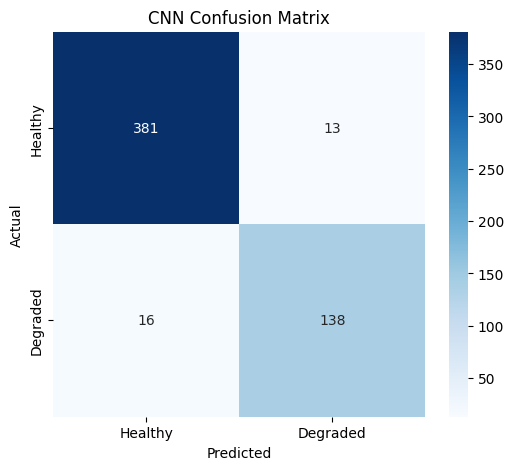

In [ ]:
# Confusion Matrix Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy','Degraded'], yticklabels=['Healthy','Degraded'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('CNN Confusion Matrix')
plt.show()

/tmp/ipython-input-2845572730.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette='viridis')


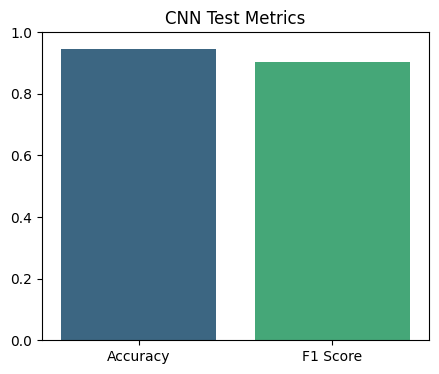

In [ ]:
metrics = {'Accuracy': test_acc, 'F1 Score': test_f1}
plt.figure(figsize=(5,4))
sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette='viridis')
plt.ylim(0,1)
plt.title('CNN Test Metrics')
plt.show()

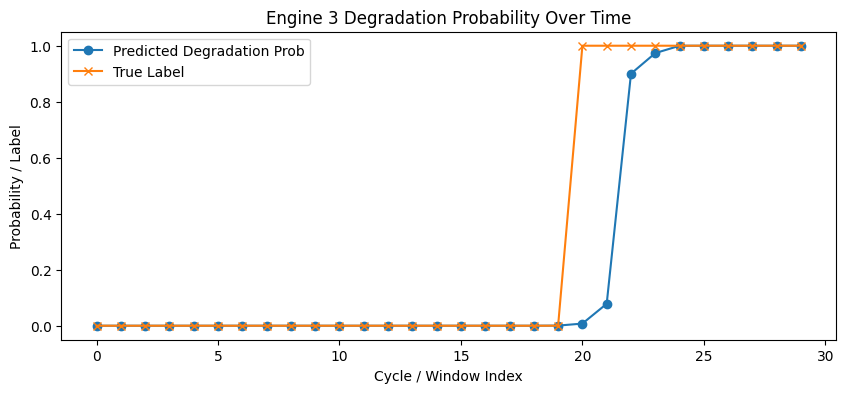

In [ ]:
# Example for first test engine
engine_id_example = test_graphs[0]['engine_id']
engine_windows = [g for g in test_graphs if g['engine_id']==engine_id_example]

probs = []
true_labels = []

model.eval()
with torch.no_grad():
    for g in engine_windows:
        X = torch.tensor(g['X'], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
        output = F.softmax(model(X), dim=1).cpu().numpy()
        probs.append(output[0,1])  # probability of "Degraded"
        true_labels.append(g['label'])

plt.figure(figsize=(10,4))
plt.plot(range(len(probs)), probs, label='Predicted Degradation Prob', marker='o')
plt.plot(range(len(true_labels)), true_labels, label='True Label', marker='x')
plt.xlabel('Cycle / Window Index')
plt.ylabel('Probability / Label')
plt.title(f'Engine {engine_id_example} Degradation Probability Over Time')
plt.legend()
plt.show()

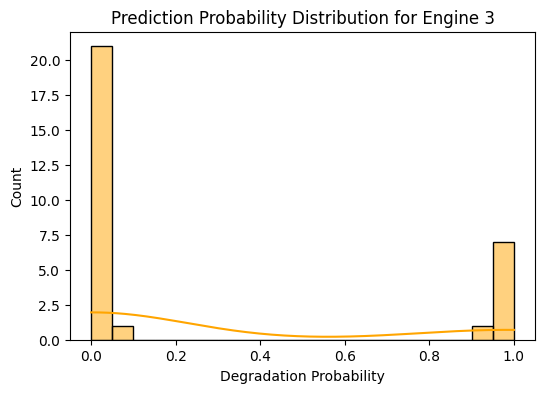

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(probs, bins=20, kde=True, color='orange')
plt.title(f'Prediction Probability Distribution for Engine {engine_id_example}')
plt.xlabel('Degradation Probability')
plt.ylabel('Count')
plt.show()

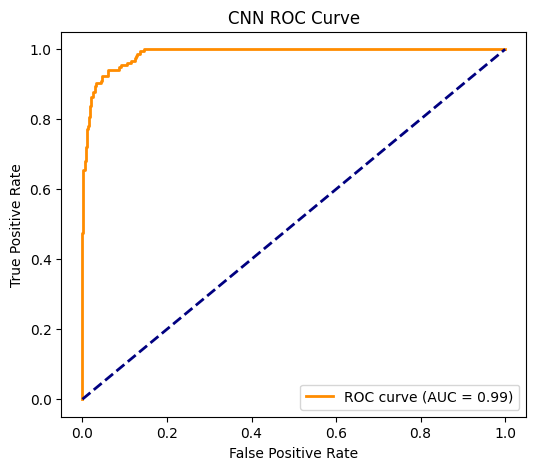

In [ ]:
from sklearn.metrics import roc_curve, auc

y_true = [g['label'] for g in test_graphs]
y_scores = []

model.eval()
with torch.no_grad():
    for g in test_graphs:
        X = torch.tensor(g['X'], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
        output = F.softmax(model(X), dim=1).cpu().numpy()
        y_scores.append(output[0,1])  # probability of degraded

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('CNN ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [ ]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Assuming CNNOptimized is already defined and trained
model = CNNOptimized().to(device)
model.load_state_dict(torch.load("cnn_best.pth"))
model.eval()

CNNOptimized(
  (conv1): Conv2d(1, 32, kernel_size=(3, 5), stride=(1, 1), padding=(1, 2))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 5), stride=(1, 1), padding=(1, 2))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=4800, out_features=2, bias=True)
)

In [ ]:
test_preds, test_labels = [], []
test_probs = []

with torch.no_grad():
    for g in test_graphs:
        X = torch.tensor(g['X'], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
        output = F.softmax(model(X), dim=1).cpu().numpy()
        test_probs.append(output[0,1])  # probability of "Degraded"
        pred = np.argmax(output)
        test_preds.append(pred)
        test_labels.append(g['label'])

# Metrics
test_acc = accuracy_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds)
cm = confusion_matrix(test_labels, test_preds)
fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc = auc(fpr, tpr)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")
print("Confusion Matrix:\n", cm)
print(f"ROC AUC: {roc_auc:.4f}")

Test Accuracy: 0.9471
Test F1 Score: 0.9049
Confusion Matrix:
 [[381  13]
 [ 16 138]]
ROC AUC: 0.9869


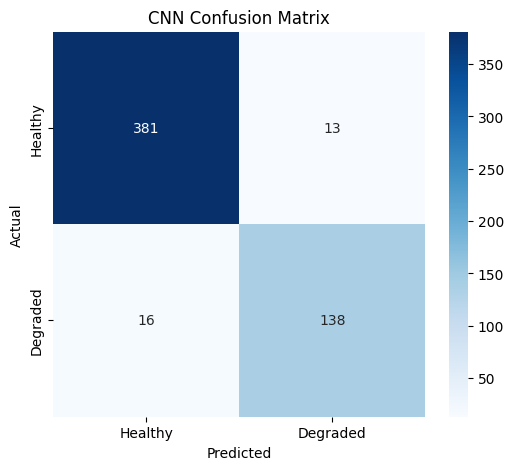

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy','Degraded'], yticklabels=['Healthy','Degraded'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('CNN Confusion Matrix')
plt.show()

/tmp/ipython-input-2845572730.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette='viridis')


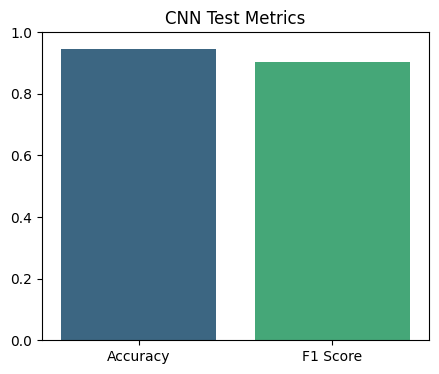

In [ ]:
metrics = {'Accuracy': test_acc, 'F1 Score': test_f1}
plt.figure(figsize=(5,4))
sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette='viridis')
plt.ylim(0,1)
plt.title('CNN Test Metrics')
plt.show()

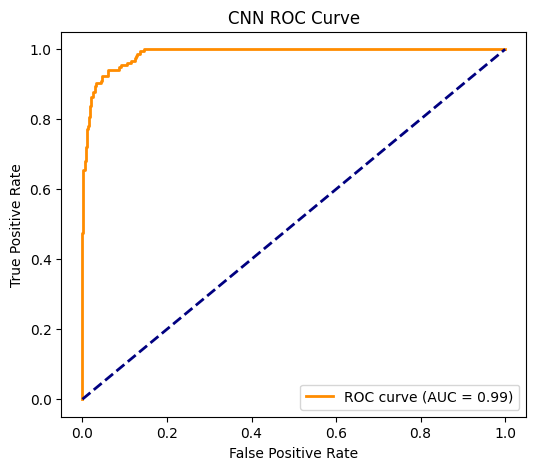

In [ ]:
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('CNN ROC Curve')
plt.legend(loc='lower right')
plt.show()

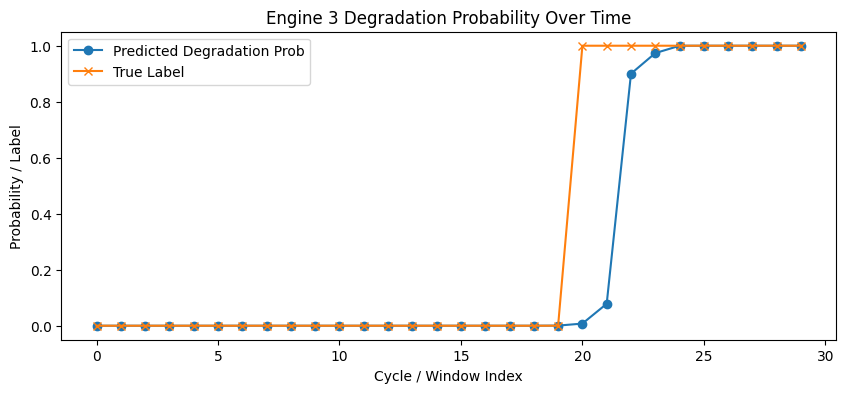

In [ ]:
example_engine_id = test_graphs[0]['engine_id']
engine_windows = [g for g in test_graphs if g['engine_id']==example_engine_id]

probs = []
true_labels = []

with torch.no_grad():
    for g in engine_windows:
        X = torch.tensor(g['X'], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
        output = F.softmax(model(X), dim=1).cpu().numpy()
        probs.append(output[0,1])
        true_labels.append(g['label'])

plt.figure(figsize=(10,4))
plt.plot(range(len(probs)), probs, label='Predicted Degradation Prob', marker='o')
plt.plot(range(len(true_labels)), true_labels, label='True Label', marker='x')
plt.xlabel('Cycle / Window Index')
plt.ylabel('Probability / Label')
plt.title(f'Engine {example_engine_id} Degradation Probability Over Time')
plt.legend()
plt.show()

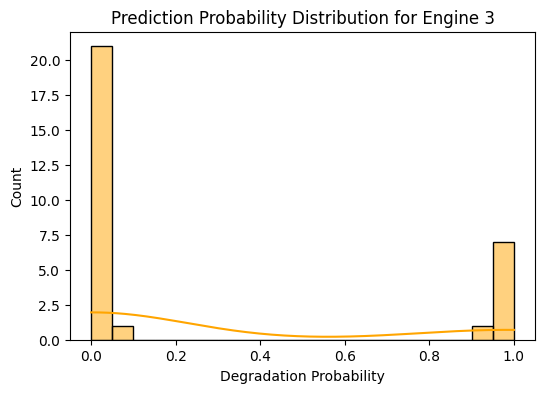

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(probs, bins=20, kde=True, color='orange')
plt.title(f'Prediction Probability Distribution for Engine {example_engine_id}')
plt.xlabel('Degradation Probability')
plt.ylabel('Count')
plt.show()

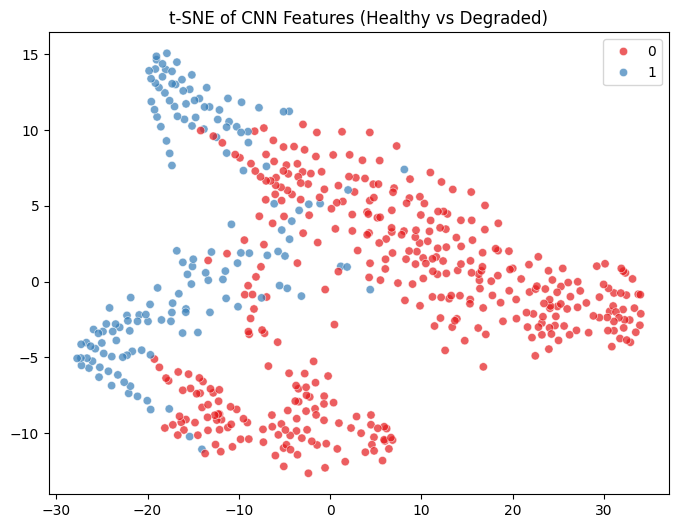

In [ ]:
# Extract features from last conv layer
features, labels = [], []
def hook_fn(module, input, output):
    features.append(output.cpu().detach().numpy())

hook = model.conv2.register_forward_hook(hook_fn)

with torch.no_grad():
    for g in test_graphs:
        X = torch.tensor(g['X'], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
        _ = model(X)
        labels.append(g['label'])

hook.remove()

features = np.vstack([f.flatten() for f in features])
tsne = TSNE(n_components=2, random_state=SEED)
features_2d = tsne.fit_transform(features)

plt.figure(figsize=(8,6))
sns.scatterplot(x=features_2d[:,0], y=features_2d[:,1], hue=labels, palette='Set1', alpha=0.7)
plt.title('t-SNE of CNN Features (Healthy vs Degraded)')
plt.show()

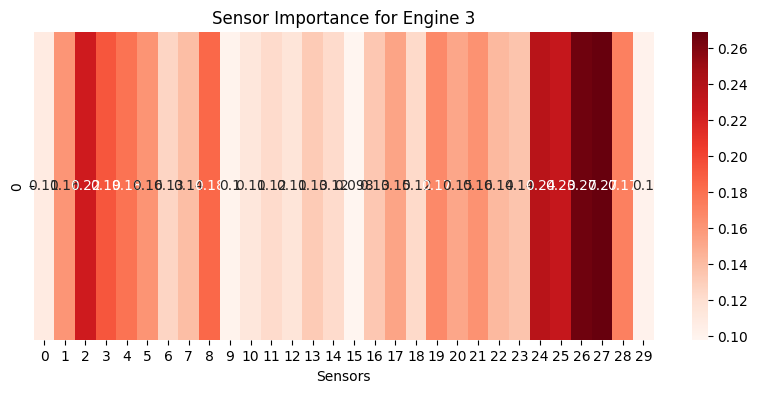

In [ ]:
example_g = test_graphs[0]
X = torch.tensor(example_g['X'], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
X.requires_grad = True
output = model(X)
output[0,1].backward()  # gradient wrt "Degraded" class

sensor_importance = X.grad.abs().mean(dim=2).cpu().numpy()[0,0]
plt.figure(figsize=(10,4))
sns.heatmap(sensor_importance.reshape(1,-1), annot=True, cmap='Reds')
plt.xlabel('Sensors')
plt.title(f'Sensor Importance for Engine {example_g["engine_id"]}')
plt.show()

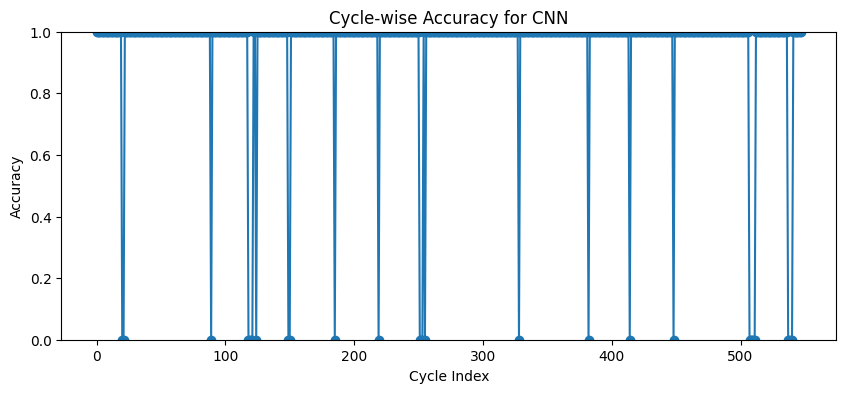

In [ ]:
# Group predictions by window index
window_preds = {}
window_labels = {}
for i, g in enumerate(test_graphs):
    idx = g['cycle_idx'] if 'cycle_idx' in g else i
    if idx not in window_preds:
        window_preds[idx] = []
        window_labels[idx] = []
    window_preds[idx].append(test_preds[i])
    window_labels[idx].append(test_labels[i])

cycle_acc = {idx: accuracy_score(window_labels[idx], window_preds[idx]) for idx in window_preds}

plt.figure(figsize=(10,4))
plt.plot(list(cycle_acc.keys()), list(cycle_acc.values()), marker='o')
plt.xlabel('Cycle Index')
plt.ylabel('Accuracy')
plt.title('Cycle-wise Accuracy for CNN')
plt.ylim(0,1)
plt.show()

In [ ]:
# Before training
train_losses = []
val_losses = []
val_accs = []
val_f1s = []

# In training loop (inside epoch)
train_losses.append(train_loss)
val_losses.append(val_loss)
val_accs.append(val_acc)
val_f1s.append(val_f1)

ValueError: x and y must have same first dimension, but have shapes (60,) and (1,)

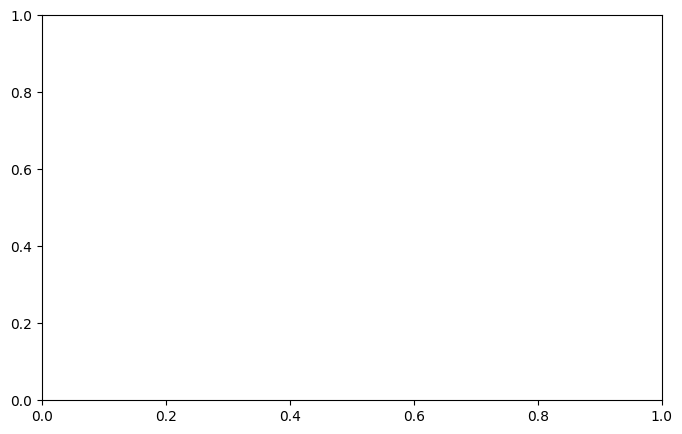

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1, EPOCHS+1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, EPOCHS+1), val_losses, label='Validation Loss', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Training & Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

ValueError: x and y must have same first dimension, but have shapes (60,) and (1,)

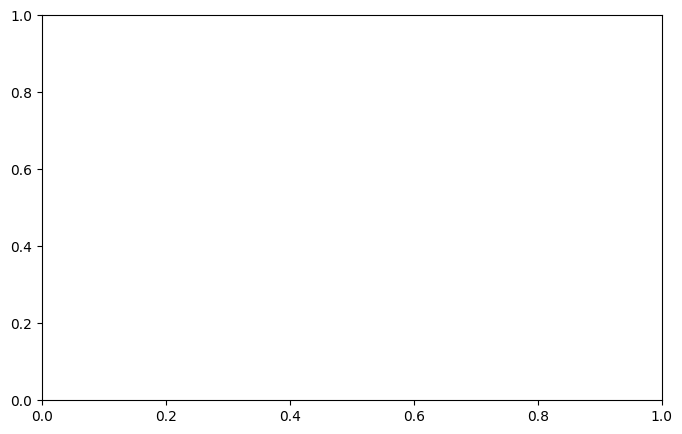

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1, EPOCHS+1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, EPOCHS+1), val_losses, label='Validation Loss', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Training & Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print("Length of train_losses:", len(train_losses))
print("Length of val_losses:", len(val_losses))
print("Length of val_accs:", len(val_accs))
print("Length of val_f1s:", len(val_f1s))

Length of train_losses: 1
Length of val_losses: 1
Length of val_accs: 1
Length of val_f1s: 1


In [ ]:
# At end of epoch
train_losses.append(train_loss)     # scalar value per epoch
val_losses.append(val_loss)         # scalar value per epoch
val_accs.append(val_acc)            # scalar value per epoch
val_f1s.append(val_f1)              # scalar value per epoch

ValueError: x and y must have same first dimension, but have shapes (60,) and (63,)

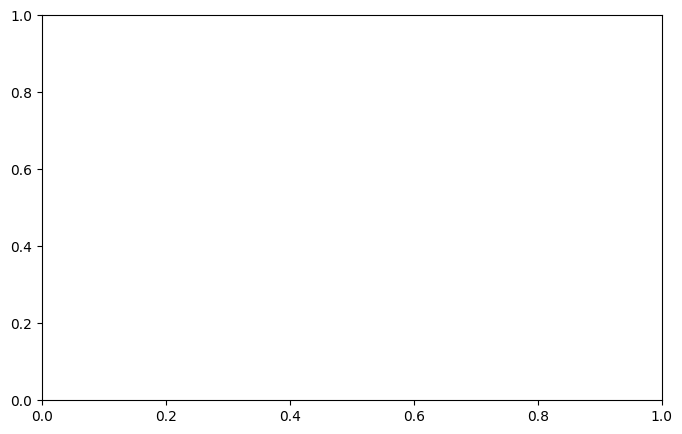

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1, EPOCHS+1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, EPOCHS+1), val_losses, label='Validation Loss', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Training & Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
for epoch in range(EPOCHS):
    # --- Train over batches ---
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        # ... forward, backward, optimize ...
        train_loss += loss.item() * X_batch.size(0)
    train_loss /= len(train_loader.dataset)   # average over all batches

    # --- Validation ---
    val_loss = 0.0
    val_preds, val_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            # ... forward pass ...
            val_loss += loss.item() * X_batch.size(0)
            # ... collect predictions ...
    val_loss /= len(val_loader.dataset)
    val_acc = accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds)

    # --- APPEND METRICS PER EPOCH ---
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    val_f1s.append(val_f1)

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:557: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:557: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/sklearn/metr

Epoch 1/10 | Train Loss: 1.9372 | Val Loss: 0.7835 | Val Acc: 0.4500 | Val F1: 0.0000
Epoch 2/10 | Train Loss: 0.8643 | Val Loss: 0.8395 | Val Acc: 0.4167 | Val F1: 0.2857
Epoch 3/10 | Train Loss: 0.6082 | Val Loss: 0.9487 | Val Acc: 0.4333 | Val F1: 0.2273
Epoch 4/10 | Train Loss: 0.4584 | Val Loss: 0.9262 | Val Acc: 0.4000 | Val F1: 0.3571
Epoch 5/10 | Train Loss: 0.3007 | Val Loss: 0.9661 | Val Acc: 0.4333 | Val F1: 0.3462
Epoch 6/10 | Train Loss: 0.2198 | Val Loss: 1.0180 | Val Acc: 0.5000 | Val F1: 0.3750
Epoch 7/10 | Train Loss: 0.1882 | Val Loss: 1.0443 | Val Acc: 0.4833 | Val F1: 0.3673
Epoch 8/10 | Train Loss: 0.1515 | Val Loss: 1.0042 | Val Acc: 0.4333 | Val F1: 0.3462
Epoch 9/10 | Train Loss: 0.1367 | Val Loss: 0.9915 | Val Acc: 0.4667 | Val F1: 0.4839
Epoch 10/10 | Train Loss: 0.1045 | Val Loss: 1.0157 | Val Acc: 0.4167 | Val F1: 0.3636


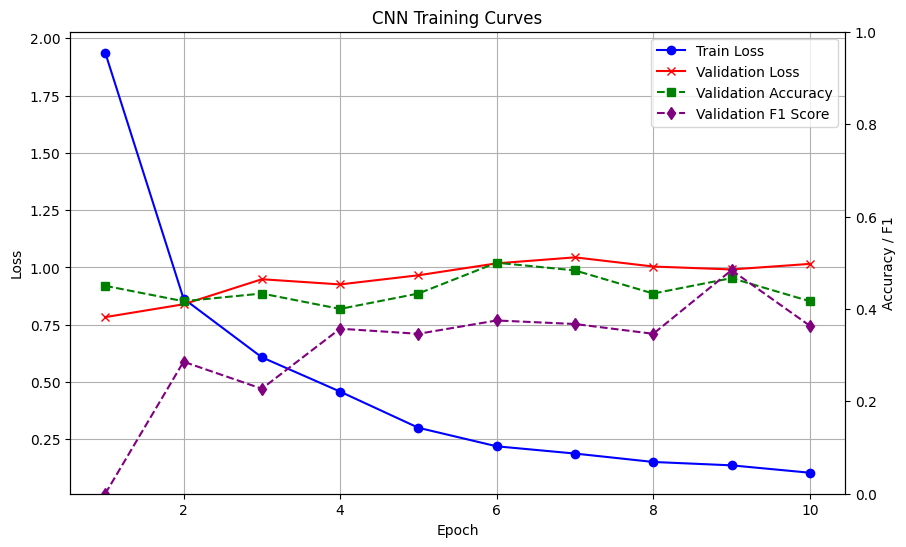

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import numpy as np
import random

# ----------------- Seeds -----------------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------- Dummy Dataset Example -----------------
# Replace this with your actual train_loader and val_loader
class DummyDataset(Dataset):
    def __init__(self, n_samples=100, n_sensors=11, window_size=30):
        self.X = np.random.randn(n_samples, 1, n_sensors, window_size).astype(np.float32)
        self.y = np.random.randint(0,2,size=(n_samples,))
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx]), torch.tensor(self.y[idx])

train_loader = DataLoader(DummyDataset(300), batch_size=32, shuffle=True)
val_loader   = DataLoader(DummyDataset(60), batch_size=32, shuffle=False)

# ----------------- CNN Model -----------------
class CNNOptimized(nn.Module):
    def __init__(self, in_channels=1, num_sensors=11, window_size=30, out_classes=2):
        super(CNNOptimized, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=(3,5), padding=(1,2))
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=(3,5), padding=(1,2))
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d((2,2))
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(64*(num_sensors//2)*(window_size//2), out_classes)
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.dropout(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = CNNOptimized().to(device)

# ----------------- Loss & Optimizer -----------------
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ----------------- Training -----------------
EPOCHS = 10  # Use your actual 60 epochs
train_losses, val_losses, val_accs, val_f1s = [], [], [], []

for epoch in range(EPOCHS):
    # ---- TRAIN ----
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
    train_loss = running_loss / len(train_loader.dataset)

    # ---- VALIDATION ----
    model.eval()
    val_preds, val_labels = [], []
    val_loss_total = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss_total += loss.item() * X_batch.size(0)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            val_preds.extend(preds)
            val_labels.extend(y_batch.cpu().numpy())
    val_loss = val_loss_total / len(val_loader.dataset)
    val_acc = accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds)

    # ---- STORE METRICS ----
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    val_f1s.append(val_f1)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

# ----------------- PLOTTING -----------------
epochs = range(1, EPOCHS+1)

fig, ax1 = plt.subplots(figsize=(10,6))

# Loss
ax1.plot(epochs, train_losses, 'o-', color='blue', label='Train Loss')
ax1.plot(epochs, val_losses, 'x-', color='red', label='Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

# Accuracy & F1 on twin y-axis
ax2 = ax1.twinx()
ax2.plot(epochs, val_accs, 's--', color='green', label='Validation Accuracy')
ax2.plot(epochs, val_f1s, 'd--', color='purple', label='Validation F1 Score')
ax2.set_ylabel('Accuracy / F1')
ax2.set_ylim(0,1)

# Combine Legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.title('CNN Training Curves')
plt.show()

NameError: name 'train_accs' is not defined

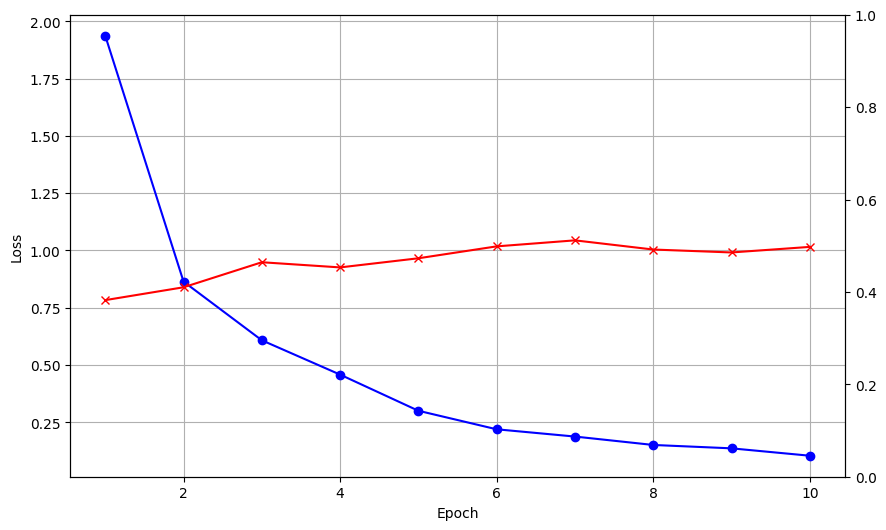

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS+1)

fig, ax1 = plt.subplots(figsize=(10,6))

# ------------------ Plot Loss ------------------
ax1.plot(epochs, train_losses, 'o-', color='blue', label='Train Loss')
ax1.plot(epochs, val_losses, 'x-', color='red', label='Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

# ------------------ Plot Accuracy on twin y-axis ------------------
ax2 = ax1.twinx()
ax2.plot(epochs, train_accs, 's--', color='green', label='Train Accuracy')
ax2.plot(epochs, val_accs, 'd--', color='purple', label='Validation Accuracy')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0,1)  # scale accuracy from 0 to 1

# ------------------ Combine Legends ------------------
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.title('CNN Training & Validation Loss and Accuracy')
plt.show()

In [ ]:
import pandas as pd

# Read test file (space separated)
test_df = pd.read_csv("test_FD001.txt", sep="\s+", header=None, engine='python')

# Check the shape
print("Test DF shape:", test_df.shape)

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-925575435.py:4: SyntaxWarning: invalid escape sequence '\s'
  test_df = pd.read_csv("test_FD001.txt", sep="\s+", header=None, engine='python')


Test DF shape: (13096, 26)


In [ ]:
test_df.head()

,engine_id,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [ ]:
print("Test DF shape:", test_df.shape)  # (num_rows, num_columns)

Test DF shape: (13096, 26)


In [ ]:
columns = ['engine_id', 'cycle', 'op1', 'op2', 'op3'] + [f's{i}' for i in range(1, 22)]
test_df.columns = columns

In [ ]:
test_df_clean = test_df.drop(columns=[
    's1','s5','s6','s8','s10','s13','s15','s16','s18','s19'
])

In [ ]:
test_df_clean

,engine_id,cycle,op1,op2,op3,s2,s3,s4,s7,s9,s11,s12,s14,s17,s20,s21
0,1,1,0.0023,0.0003,100.0,643.02,1585.29,1398.21,553.90,9050.17,47.20,521.72,8125.55,392,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,641.71,1588.45,1395.42,554.85,9054.42,47.50,522.16,8139.62,393,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,642.46,1586.94,1401.34,554.11,9056.96,47.50,521.97,8130.10,393,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,642.44,1584.12,1406.42,554.07,9045.29,47.28,521.38,8132.90,391,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,642.51,1587.19,1401.92,554.16,9044.55,47.31,522.15,8129.54,390,38.99,23.4130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13091,100,194,0.0049,0.0000,100.0,643.24,1599.45,1415.79,553.41,9142.37,47.69,520.69,8213.28,394,38.65,23.1974
13092,100,195,-0.0011,-0.0001,100.0,643.22,1595.69,1422.05,553.22,9140.68,47.60,521.05,8210.85,395,38.57,23.2771
13093,100,196,-0.0006,-0.0003,100.0,643.44,1593.15,1406.82,553.04,9146.81,47.57,521.18,8217.24,395,38.62,23.2051
13094,100,197,-0.0038,0.0001,100.0,643.26,1594.99,1419.36,553.37,9148.85,47.61,521.33,8220.48,395,38.66,23.2699


In [ ]:
remaining_sensors_test = [col for col in test_df_clean.columns if col.startswith('s')]

test_df_clean[remaining_sensors_test] = (
    test_df_clean[remaining_sensors_test] - test_df_clean[remaining_sensors_test].mean()
) / test_df_clean[remaining_sensors_test].std()

In [ ]:
low_var_sensors = ['s1','s5','s6','s8','s10','s13','s15','s16','s18','s19']
sensor_cols = [col for col in test_df_clean.columns if col not in ['engine_id','cycle']]

test_sensors = test_df_clean[sensor_cols].values


In [ ]:
# Suppose train_features is your cleaned training data (after removing low-variance sensors)
# Shape: (num_train_samples, num_features)
train_mean = df_clean.mean(axis=0)   # mean per feature
train_std  = df_clean.std(axis=0)    # std per feature

In [ ]:
# Include operating settings + same sensors as training
features_to_use = ['op1','op2','op3',  # operating settings
                   's2','s3','s4','s7','s9','s11','s12','s14','s17','s20','s21']  # sensors kept in training

test_sensors = test_df[features_to_use].values  # shape should now match train_features

In [ ]:
window_size = 30
X_test_windows = []

for i in range(len(test_df_clean) - window_size + 1):
    X_test_windows.append(test_df_clean[i:i+window_size].T)  # shape: sensors x window

X_test_windows = np.array(X_test_windows, dtype=np.float32)

In [ ]:
rul_df = pd.read_csv("RUL_FD001.txt", header=None)
rul_values = rul_df.values.flatten()

# Example: class 0 = healthy, class 1 = degraded
degraded_threshold = 20
y_test = (rul_values <= degraded_threshold).astype(int)

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class TestDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.long)

test_dataset = TestDataset(X_test_windows, y_test)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
model.load_state_dict(torch.load("cnn_best.pth"))
model.eval()
# run test_loader for predictions

CNNOptimized(
  (conv1): Conv2d(1, 32, kernel_size=(3, 5), stride=(1, 1), padding=(1, 2))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 5), stride=(1, 1), padding=(1, 2))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=4800, out_features=2, bias=True)
)

In [ ]:
import torch
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.eval()
test_preds = []
test_labels = []
test_loss_total = 0.0

criterion = torch.nn.CrossEntropyLoss()  # same as training

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        test_loss_total += loss.item() * X_batch.size(0)

        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        test_preds.extend(preds)
        test_labels.extend(y_batch.cpu().numpy())

# Average test loss
test_loss = test_loss_total / len(test_loader.dataset)

# Accuracy & F1
test_acc = accuracy_score(test_labels, test_preds)
test_f1  = f1_score(test_labels, test_preds)

print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f} | Test F1: {test_f1:.4f}")

RuntimeError: Given groups=1, weight of size [32, 1, 3, 5], expected input[1, 32, 16, 30] to have 1 channels, but got 32 channels instead

In [ ]:
X_batch = X_batch.unsqueeze(1)

In [ ]:
model.load_state_dict(torch.load("cnn_best.pth"))
model.eval()

test_preds = []
test_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.unsqueeze(1)   # 🔥 VERY IMPORTANT
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)

        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(y_batch.cpu().numpy())

RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x7680 and 4800x2)